✅ Python 脚本

In [1]:
import json
from collections import Counter
import numpy as np

# ====== 文件路径 ======
file_path = "Hope-EXP datasets/HopeEXP_Train.jsonl"

# ====== 统计容器 ======
primary_label_counter = Counter()
trigger_emotions_counter = Counter()
lang_counter = Counter()

title_lengths = []
selftext_lengths = []

# ====== 读取数据 ======
with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        data = json.loads(line.strip())

        # -------- primary_label --------
        if "primary_label" in data and data["primary_label"] is not None:
            primary_label_counter[data["primary_label"]] += 1

        # -------- trigger_emotions --------
        # 可能是 list / str
        if "trigger_emotions" in data and data["trigger_emotions"] is not None:
            emotions = data["trigger_emotions"]
            if isinstance(emotions, list):
                for emo in emotions:
                    trigger_emotions_counter[emo] += 1
            else:
                trigger_emotions_counter[emotions] += 1

        # -------- lang --------
        if "lang" in data and data["lang"] is not None:
            lang_counter[data["lang"]] += 1

        # -------- title 长度 --------
        if "title" in data and data["title"]:
            title_lengths.append(len(data["title"]))

        # -------- selftext 长度 --------
        if "selftext" in data and data["selftext"]:
            selftext_lengths.append(len(data["selftext"]))


# ====== 打印统计函数 ======
def print_counter(counter, name, topk=20):
    print(f"\n===== {name} 分布 (Top {topk}) =====")
    total = sum(counter.values())
    for k, v in counter.most_common(topk):
        print(f"{k}: {v} ({v/total:.2%})")
    print(f"总计: {total}")


def print_length_stats(lengths, name):
    if not lengths:
        print(f"\n{name} 无数据")
        return

    arr = np.array(lengths)
    print(f"\n===== {name} 长度统计 =====")
    print(f"样本数: {len(arr)}")
    print(f"平均值: {arr.mean():.2f}")
    print(f"最小值: {arr.min()}")
    print(f"最大值: {arr.max()}")
    print(f"中位数: {np.median(arr):.2f}")
    print(f"90分位: {np.percentile(arr, 90):.2f}")
    print(f"95分位: {np.percentile(arr, 95):.2f}")


# ====== 输出结果 ======
print_counter(primary_label_counter, "primary_label")
print_counter(trigger_emotions_counter, "trigger_emotions")
print_counter(lang_counter, "lang")

print_length_stats(title_lengths, "title")
print_length_stats(selftext_lengths, "selftext")


===== primary_label 分布 (Top 20) =====
Not Hope: 1400 (28.82%)
General Hope: 937 (19.29%)
Realistic Hope: 701 (14.43%)
Sarcastic Hope: 700 (14.41%)
Unrealistic Hope: 700 (14.41%)
Hopelessness: 419 (8.63%)
总计: 4857

===== trigger_emotions 分布 (Top 20) =====
sadness: 2438 (31.32%)
anger: 1335 (17.15%)
Nuetral/unclear: 1277 (16.41%)
fear: 1119 (14.38%)
joy: 614 (7.89%)
love: 611 (7.85%)
surprise: 389 (5.00%)
总计: 7783

===== lang 分布 (Top 20) =====
ES: 2614 (53.82%)
EN: 2243 (46.18%)
总计: 4857

===== title 长度统计 =====
样本数: 4857
平均值: 54.22
最小值: 3
最大值: 300
中位数: 50.00
90分位: 89.00
95分位: 102.20

===== selftext 长度统计 =====
样本数: 4852
平均值: 1095.95
最小值: 1
最大值: 32289
中位数: 890.00
90分位: 1930.60
95分位: 2812.05


🔥 额外建议（强烈推荐）

如果你后续要做建模（你前面已经在做 ML），可以再加这几个统计：

1️⃣ 文本长度分布图

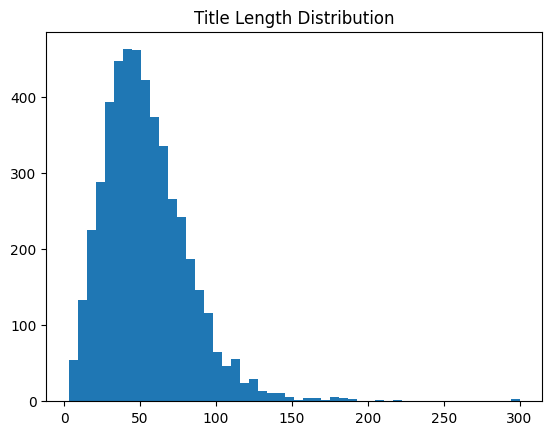

In [2]:
import matplotlib.pyplot as plt

plt.hist(title_lengths, bins=50)
plt.title("Title Length Distribution")
plt.show()

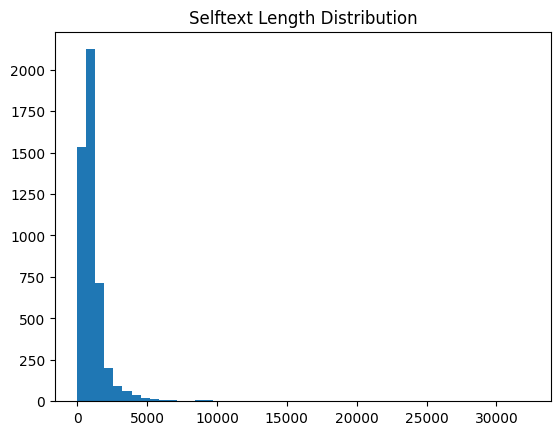

In [7]:
import matplotlib.pyplot as plt

plt.hist(selftext_lengths, bins=50)
plt.title("Selftext Length Distribution")
plt.show()

2️⃣ 标签不平衡检查

In [3]:
print("\n最少类别样本数:", min(primary_label_counter.values()))
print("最多类别样本数:", max(primary_label_counter.values()))


最少类别样本数: 419
最多类别样本数: 1400


3️⃣ trigger_emotions 多标签密度

In [4]:
emotion_per_sample = []

with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        data = json.loads(line.strip())
        emotions = data.get("trigger_emotions", [])
        if isinstance(emotions, list):
            emotion_per_sample.append(len(emotions))
        elif emotions:
            emotion_per_sample.append(1)

print("平均每条样本 emotion 数:", np.mean(emotion_per_sample))

平均每条样本 emotion 数: 1.6024294832200947


In [9]:
import json
from collections import Counter
import numpy as np

# ====== 文件路径 ======
file_path = "Hope-EXP datasets/HopeEXP_Test_unlabeled.jsonl"

# ====== 统计容器 ======
primary_label_counter = Counter()
trigger_emotions_counter = Counter()
lang_counter = Counter()

title_lengths = []
selftext_lengths = []

# ====== 读取数据 ======
with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        data = json.loads(line.strip())

        # -------- primary_label --------
        if "primary_label" in data and data["primary_label"] is not None:
            primary_label_counter[data["primary_label"]] += 1

        # -------- trigger_emotions --------
        # 可能是 list / str
        if "trigger_emotions" in data and data["trigger_emotions"] is not None:
            emotions = data["trigger_emotions"]
            if isinstance(emotions, list):
                for emo in emotions:
                    trigger_emotions_counter[emo] += 1
            else:
                trigger_emotions_counter[emotions] += 1

        # -------- lang --------
        if "lang" in data and data["lang"] is not None:
            lang_counter[data["lang"]] += 1

        # -------- title 长度 --------
        if "title" in data and data["title"]:
            title_lengths.append(len(data["title"]))

        # -------- selftext 长度 --------
        if "selftext" in data and data["selftext"]:
            selftext_lengths.append(len(data["selftext"]))


# ====== 打印统计函数 ======
def print_counter(counter, name, topk=20):
    print(f"\n===== {name} 分布 (Top {topk}) =====")
    total = sum(counter.values())
    for k, v in counter.most_common(topk):
        print(f"{k}: {v} ({v/total:.2%})")
    print(f"总计: {total}")


def print_length_stats(lengths, name):
    if not lengths:
        print(f"\n{name} 无数据")
        return

    arr = np.array(lengths)
    print(f"\n===== {name} 长度统计 =====")
    print(f"样本数: {len(arr)}")
    print(f"平均值: {arr.mean():.2f}")
    print(f"最小值: {arr.min()}")
    print(f"最大值: {arr.max()}")
    print(f"中位数: {np.median(arr):.2f}")
    print(f"90分位: {np.percentile(arr, 90):.2f}")
    print(f"95分位: {np.percentile(arr, 95):.2f}")


# ====== 输出结果 ======
print_counter(primary_label_counter, "primary_label")
print_counter(trigger_emotions_counter, "trigger_emotions")
print_counter(lang_counter, "lang")

print_length_stats(title_lengths, "title")
print_length_stats(selftext_lengths, "selftext")


===== primary_label 分布 (Top 20) =====
总计: 0

===== trigger_emotions 分布 (Top 20) =====
总计: 0

===== lang 分布 (Top 20) =====
ES: 1087 (52.21%)
EN: 995 (47.79%)
总计: 2082

===== title 长度统计 =====
样本数: 2082
平均值: 54.88
最小值: 1
最大值: 265
中位数: 50.00
90分位: 89.00
95分位: 107.00

===== selftext 长度统计 =====
样本数: 2078
平均值: 1059.57
最小值: 6
最大值: 27533
中位数: 877.00
90分位: 1888.00
95分位: 2599.80
